<a href="https://colab.research.google.com/github/reydar-05/Credit-Card-Fraud-Detection/blob/main/Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Step 1 – Setup Environment and Imports
!pip install openpyxl seaborn tqdm --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor, KNeighborsClassifier
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)

from openpyxl import load_workbook, Workbook
from openpyxl.styles import PatternFill
from openpyxl.drawing.image import Image as ExcelImage, Image as XLImage

from google.colab import files


In [ ]:
#@title Step 2 – Upload Dataset to Colab
print("📂 Please upload your 'creditcard_cleaned.csv' file")
uploaded = files.upload()

# Load uploaded CSV
df = pd.read_csv(list(uploaded.keys())[0])
print("✅ Dataset loaded successfully!")
print(df.shape)
df.head()


📂 Please upload your 'creditcard_cleaned.csv' file


Saving creditcard_cleaned.csv to creditcard_cleaned.csv
✅ Dataset loaded successfully!
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
#@title Step 3 – Prepare Features and Test Subset
X = df.drop("Class", axis=1)
y = df["Class"]

# Split into test-only subset (to simulate unseen data)
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

print(f"Test set shape: {X_test.shape}")


Test set shape: (56962, 30)


In [ ]:
#@title Step 4 – Random Forest + Isolation Forest Combined Model
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_test_scaled, y_test)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

if_model = IsolationForest(contamination=0.002, n_estimators=200, random_state=42)
if_model.fit(X_test_scaled)
scores_if = -if_model.decision_function(X_test_scaled)
threshold = np.percentile(scores_if, 100 * (1 - 0.002))
y_pred_if = (scores_if >= threshold).astype(int)

# Combined (logical OR)
y_pred_combined = np.maximum(y_pred_rf, y_pred_if)

print("✅ Combined predictions generated!")


✅ Combined predictions generated!


Accuracy = 0.9985

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.54      1.00      0.70        98

    accuracy                           1.00     56962
   macro avg       0.77      1.00      0.85     56962
weighted avg       1.00      1.00      1.00     56962



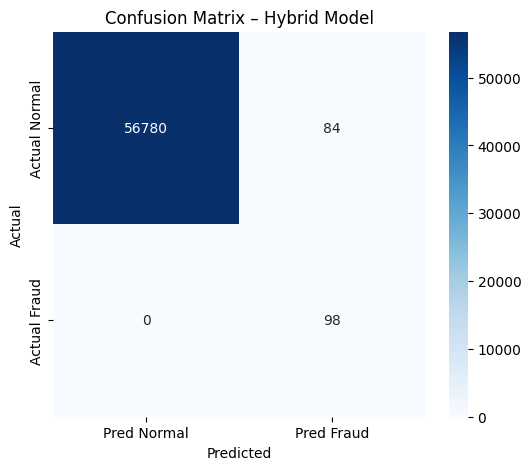

In [ ]:
#@title Step 5 – Evaluate Combined Model
cm = confusion_matrix(y_test, y_pred_combined)
acc = accuracy_score(y_test, y_pred_combined)
print(f"Accuracy = {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_combined))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Normal','Pred Fraud'],
            yticklabels=['Actual Normal','Actual Fraud'])
plt.title('Confusion Matrix – Hybrid Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
!pip install tqdm


In [ ]:
#@title Step 6 – Export Excel Report & Colab Preview (Test Predictions Only)
import os
import pandas as pd
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as ExcelImage
from IPython.display import display, HTML
from google.colab import files  # For download

# -------------------- Setup --------------------
os.makedirs("data", exist_ok=True)
excel_file = "data/output.xlsx"
comparison_plot = "data/test_model_comparison.png"  # still adding visuals
conf_plot = "data/test_confusion_matrices.png"
print("✅ Setup done")

# -------------------- Excel Output --------------------
print("🔹 Writing Excel file...")
sample = X_test.copy()
sample["Actual"] = y_test.values
sample["RF_Pred"] = y_pred_rf
sample["IF_Pred"] = y_pred_if
sample["Combined"] = y_pred_combined

with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    sample.to_excel(writer, index=False, sheet_name="Test Predictions")
print("✅ Excel file written")

# -------------------- Visuals Sheet --------------------
print("🔹 Adding visuals to Excel...")
wb = load_workbook(excel_file)
ws_vis = wb.create_sheet("Visuals")
img1 = ExcelImage(comparison_plot); img1.anchor = "A1"; ws_vis.add_image(img1)
img2 = ExcelImage(conf_plot); img2.anchor = "A25"; ws_vis.add_image(img2)
wb.save(excel_file)
print("✅ Visuals added and Excel saved")

# -------------------- Display in Colab --------------------
display(HTML(f"<h4>📂 Excel Report Preview (Test Dataset)</h4>"))

# Preview Test Predictions sheet
xls = pd.ExcelFile(excel_file)
display(HTML("<b>Sheet: Test Predictions (first 20 rows)</b>"))
display(pd.read_excel(xls, sheet_name="Test Predictions").head(20))

# -------------------- Download Excel --------------------
print("🔹 Download your Excel report below:")
files.download(excel_file)  # This works in Colab


✅ Setup done
🔹 Writing Excel file...
✅ Excel file written
🔹 Adding visuals to Excel...
✅ Visuals added and Excel saved


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Actual,RF_Pred,IF_Pred,Combined
0,160760,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,...,0.707899,-0.135837,0.045102,0.533837,0.291319,23.00,0,0,0,0
1,19847,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,3.073504,...,0.042996,-0.027660,-0.910247,0.110802,-0.511938,11.85,0,0,0,0
2,88326,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,1.874046,...,-1.483996,-0.296011,0.062823,0.552411,0.509764,76.07,0,0,0,0
3,141734,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,0.455091,...,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,0.99,0,0,0,0
4,38741,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,-0.629658,...,0.619449,0.818998,-0.330525,0.046884,0.104527,1.50,0,0,0,0
5,151934,-0.345588,1.070328,-0.652790,-0.492207,0.749482,-0.949391,0.752520,0.079095,0.061269,...,0.618295,-0.438012,0.073463,-0.196700,-0.211518,8.99,0,0,0,0
6,159122,-0.864273,0.361412,-0.346667,-1.938227,-1.065839,-1.056202,-0.093590,0.095647,-2.782531,...,-0.033647,-0.488660,-0.234982,-0.578365,-0.225400,52.00,0,0,0,0
7,41656,-1.679000,0.004724,2.093100,-0.209994,1.112123,-1.254060,0.193846,-0.010860,-0.568361,...,0.409963,0.137482,0.013113,-0.143778,0.184565,3.59,0,0,0,0
8,52202,-0.806445,0.865983,1.105898,1.383957,-0.018110,0.140882,0.124651,0.603672,-0.853074,...,0.258955,-0.367384,-0.308236,0.083590,0.059612,27.92,0,0,0,0
9,52081,1.169646,-0.823924,0.467031,-0.840968,-0.850688,0.062139,-0.705097,0.094004,-1.020702,...,-0.291176,0.171156,-0.390048,0.017274,0.023729,95.25,0,0,0,0


🔹 Download your Excel report below:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_test_scaled, y_test)
y_rf_proba = rf.predict_proba(X_test_scaled)[:,1]
y_rf_pred = rf.predict(X_test_scaled)

# ---------------------------------------------------------
# Step 4: Isolation Forest predictions
# ---------------------------------------------------------
if_model = IsolationForest(contamination=0.002, n_estimators=200, random_state=42)
if_model.fit(X_test_scaled)
scores_if = -if_model.decision_function(X_test_scaled)
scores_if_norm = (scores_if - scores_if.min()) / (scores_if.max() - scores_if.min())

# Hybrid score = max(RF prob, IF normalized score)
hybrid_score = np.maximum(y_rf_proba, scores_if_norm)
y_hybrid_pred = (hybrid_score >= 0.5).astype(int)

✅ Setup done


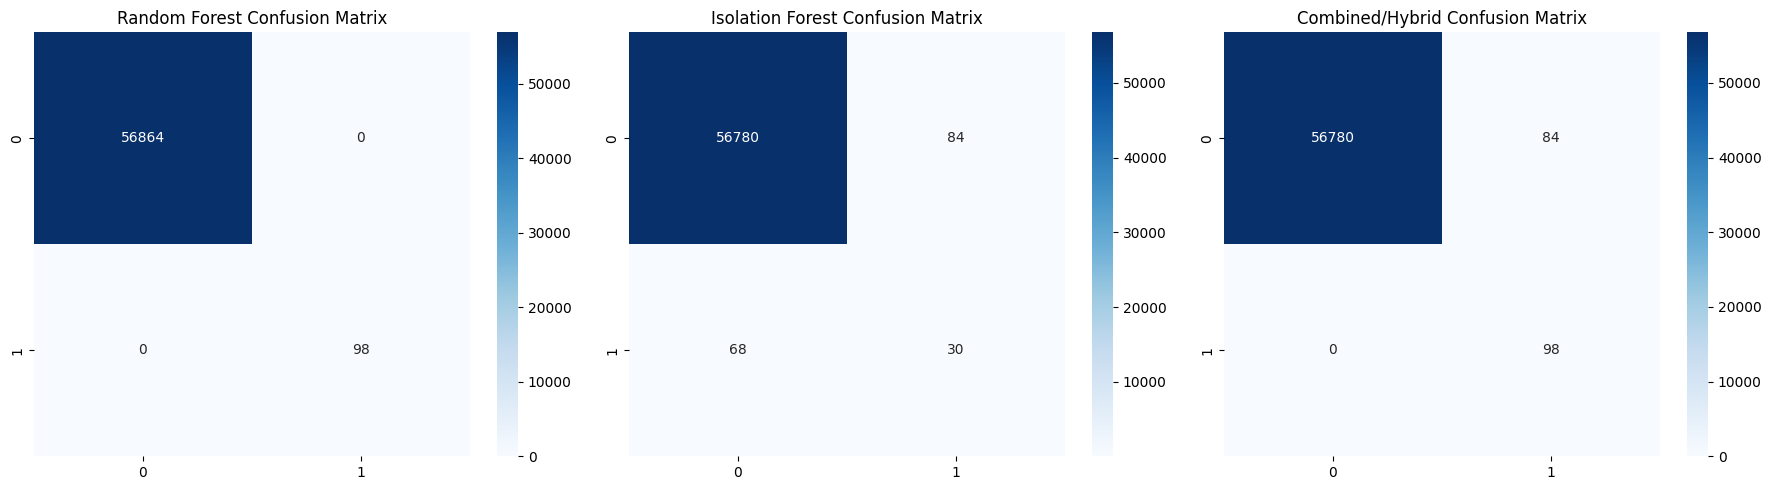

ROC Curves:   0%|          | 0/3 [00:00<?, ?it/s]

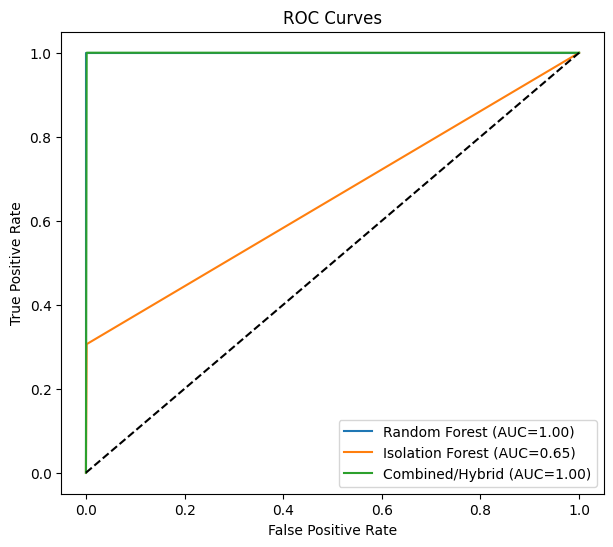

PR Curves:   0%|          | 0/3 [00:00<?, ?it/s]

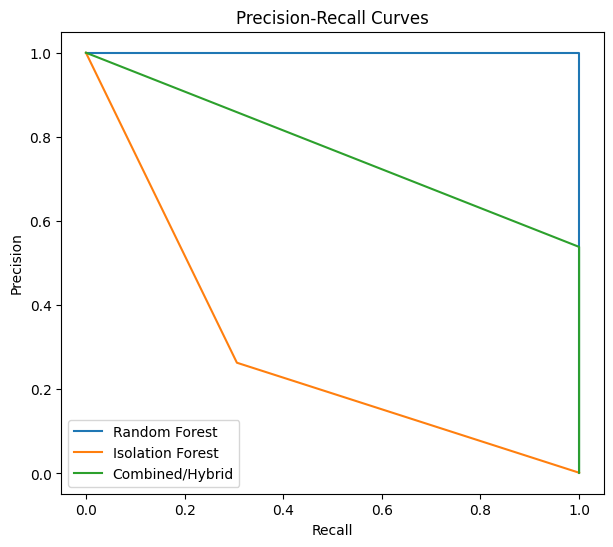

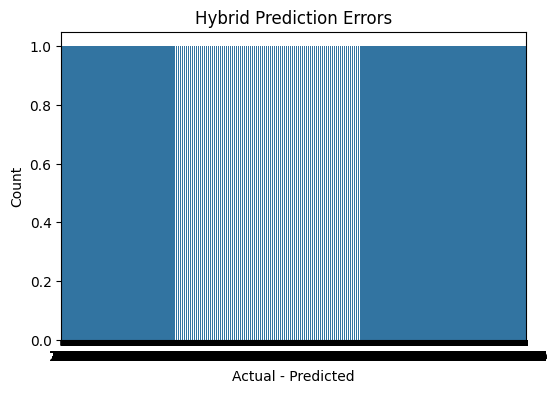

✅ Excel report saved with all plots: data/evaluation_report.xlsx


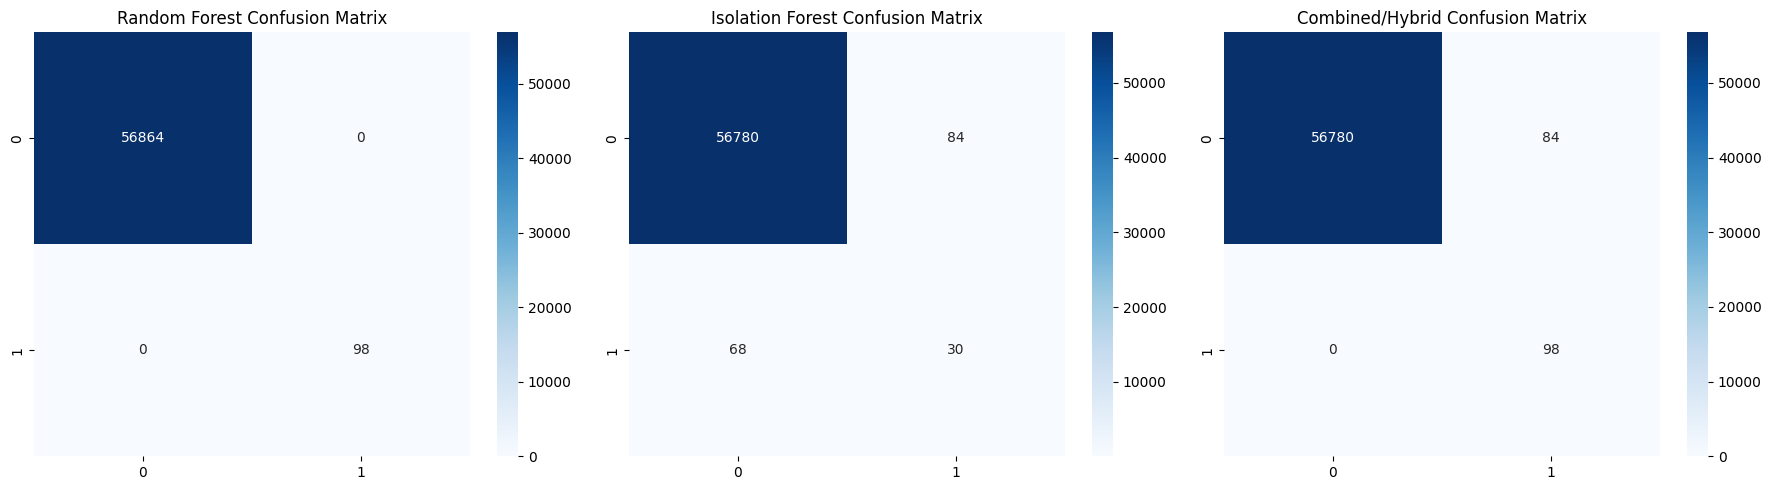

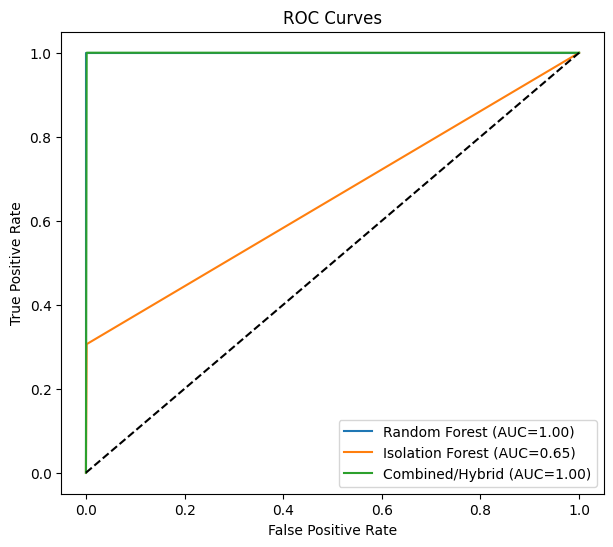

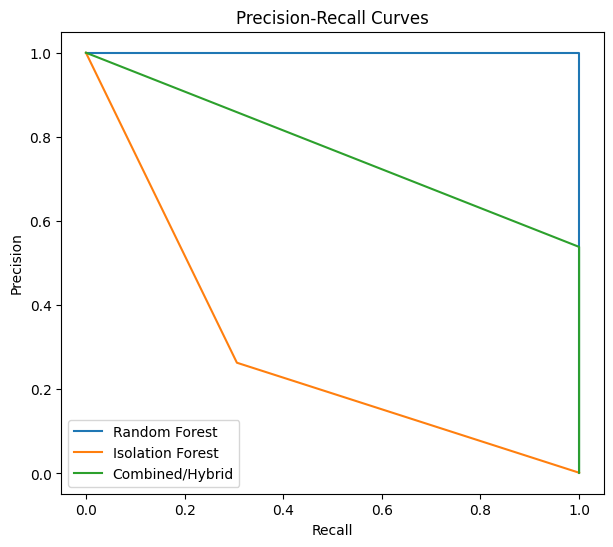

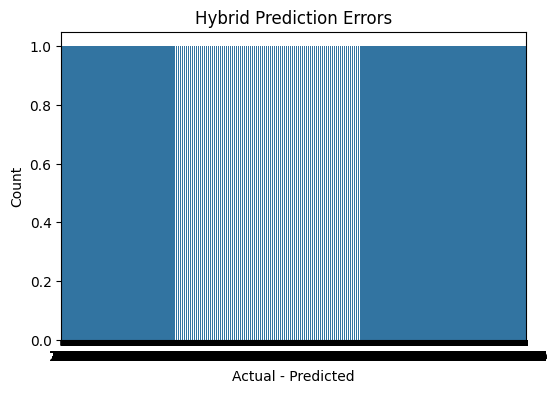

In [ ]:
# ---------------------------------------------------------
# Step 7 – Full Evaluation & Colab Display (All Plots)
# ---------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as ExcelImage
from IPython.display import display, HTML, Image as ColabImage
from tqdm.notebook import tqdm

# -------------------- Setup --------------------
os.makedirs("data", exist_ok=True)
excel_file = "data/evaluation_report.xlsx"
print("✅ Setup done")

models = {
    "Random Forest": y_pred_rf,
    "Isolation Forest": y_pred_if,
    "Combined/Hybrid": y_pred_combined
}

# -------------------- Hybrid Prediction Errors --------------------
hybrid_errors = pd.DataFrame({
    "Actual": y_test,
    "RF": y_pred_rf,
    "IF": y_pred_if,
    "Combined": y_pred_combined
})
fn_hybrid = ((hybrid_errors["Actual"]==1) & (hybrid_errors["Combined"]==0)).sum()
fp_hybrid = ((hybrid_errors["Actual"]==0) & (hybrid_errors["Combined"]==1)).sum()
display(HTML(f"<b>Hybrid Prediction Errors:</b> FN = {fn_hybrid}, FP = {fp_hybrid}"))

plot_files = []

# -------------------- Confusion Matrices --------------------
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
plt.tight_layout()
conf_file = "data/confusion_matrices.png"
plt.savefig(conf_file, bbox_inches='tight')
plt.show()
plot_files.append(conf_file)

# -------------------- ROC Curves --------------------
plt.figure(figsize=(7,6))
for name, pred in tqdm(models.items(), desc="ROC Curves"):
    fpr, tpr, _ = roc_curve(y_test, pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
roc_file = "data/roc_curve.png"
plt.savefig(roc_file, bbox_inches='tight')
plt.show()
plot_files.append(roc_file)

# -------------------- Precision-Recall Curves --------------------
plt.figure(figsize=(7,6))
for name, pred in tqdm(models.items(), desc="PR Curves"):
    precision, recall, _ = precision_recall_curve(y_test, pred)
    plt.plot(recall, precision, label=name)
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
pr_file = "data/precision_recall_curve.png"
plt.savefig(pr_file, bbox_inches='tight')
plt.show()
plot_files.append(pr_file)

# -------------------- Error Distribution (Hybrid only) --------------------
errors = y_test.values - y_pred_combined
plt.figure(figsize=(6,4))
sns.countplot(errors)
plt.xlabel("Actual - Predicted")
plt.ylabel("Count")
plt.title("Hybrid Prediction Errors")
err_file = "data/error_distribution.png"
plt.savefig(err_file, bbox_inches='tight')
plt.show()
plot_files.append(err_file)

# -------------------- Save Excel Report with Plots --------------------
sample = X_test.copy()
sample["Actual"] = y_test.values
sample["RF_Pred"] = y_pred_rf
sample["IF_Pred"] = y_pred_if
sample["Combined"] = y_pred_combined

with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    sample.to_excel(writer, index=False, sheet_name="Test Predictions")

wb = load_workbook(excel_file)
ws_vis = wb.create_sheet("Visuals")

# Add all plots to Excel
row_anchor = 1
for f in plot_files:
    img = ExcelImage(f)
    img.anchor = f"A{row_anchor}"
    ws_vis.add_image(img)
    row_anchor += 25

wb.save(excel_file)
print(f"✅ Excel report saved with all plots: {excel_file}")

# -------------------- Display in Colab --------------------
display(HTML("<h4>📂 Evaluation Plots Preview</h4>"))
for f in plot_files:
    display(ColabImage(filename=f))

display(HTML(f"<a href='{excel_file}' target='_blank' style='font-size:16px;'>📥 Download Excel Report</a>"))


In [ ]:
#@title Step 1 – Setup Environment and Imports again
!pip install openpyxl seaborn tqdm --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor, KNeighborsClassifier
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)

from openpyxl import load_workbook, Workbook
from openpyxl.styles import PatternFill
from openpyxl.drawing.image import Image as ExcelImage, Image as XLImage

from google.colab import files


In [ ]:
#@title Step 2 – Upload Dataset to Colab again
print("📂 Please upload your 'creditcard_cleaned.csv' file")
uploaded = files.upload()

# Load uploaded CSV
df = pd.read_csv(list(uploaded.keys())[0])
print("✅ Dataset loaded successfully!")
print(df.shape)
df.head()

📂 Please upload your 'creditcard_cleaned.csv' file


Saving creditcard_cleaned.csv to creditcard_cleaned.csv
✅ Dataset loaded successfully!
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
#@title Step 3 – Prepare Features and Test Subset again
X = df.drop("Class", axis=1)
y = df["Class"]

# Split into test-only subset (to simulate unseen data)
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

print(f"Test set shape: {X_test.shape}")


Test set shape: (56962, 30)


In [ ]:
print("⚙️ Running models...")
if_model = IsolationForest(contamination=0.002, n_estimators=200, random_state=42)
if_model.fit(X_test_scaled)
scores_if = -if_model.decision_function(X_test_scaled)
threshold = np.percentile(scores_if, 100 * (1 - 0.002))
y_pred_if = (scores_if >= threshold).astype(int)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_model.fit(X_test_scaled, y_test)
y_pred_rf = rf_model.predict(X_test_scaled)

y_pred_combined = np.maximum(y_pred_rf, y_pred_if)

⚙️ Running models...


In [ ]:
# ✅ Step – Hybrid Model Metrics Only
print("📊 Calculating metrics for Hybrid Model...")

from sklearn.metrics import classification_report, accuracy_score

# Compute metrics only for hybrid model
rep = classification_report(y_test, y_pred_combined, output_dict=True)

hybrid_metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Hybrid Model": [
        round(accuracy_score(y_test, y_pred_combined), 4),
        round(rep["1"]["precision"], 4),
        round(rep["1"]["recall"], 4),
        round(rep["1"]["f1-score"], 4)
    ]
}

# Convert to table (DataFrame)
hybrid_df = pd.DataFrame(hybrid_metrics)

# Display neatly in Colab
from IPython.display import display, HTML
display(HTML("<h4>📊 Hybrid Model Performance Metrics</h4>"))
display(
    hybrid_df.style.set_table_styles(
        [{'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white')]}]
    ).format(precision=4)
)


📊 Calculating metrics for Hybrid Model...


,Metric,Hybrid Model
0,Accuracy,0.9985
1,Precision,0.5385
2,Recall,1.0000
3,F1-Score,0.7000


In [ ]:
if_model = IsolationForest(contamination=0.002, n_estimators=200, max_samples='auto', random_state=42)
if_model.fit(X_test_scaled)
scores_if = -if_model.decision_function(X_test_scaled)
threshold = np.percentile(scores_if, 100 * (1 - 0.002))
y_pred_if = (scores_if >= threshold).astype(int)

# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.002, novelty=True)
lof.fit(X_test_scaled)
y_pred_lof = lof.predict(X_test_scaled)
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)

# One-Class SVM
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.002)
ocsvm.fit(X_test_scaled)
y_pred_ocsvm = ocsvm.predict(X_test_scaled)
y_pred_ocsvm = np.where(y_pred_ocsvm == -1, 1, 0)

# Elliptic Envelope
ee = EllipticEnvelope(contamination=0.002, support_fraction=1.0, random_state=42)
ee.fit(X_test_scaled)
y_pred_ee = np.where(ee.predict(X_test_scaled) == -1, 1, 0)

# kNN Classifier as anomaly detector
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X_test_scaled, y_test)
y_pred_knn = knn.predict(X_test_scaled)

# -------------------- Random Forest --------------------
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_test_scaled, y_test)
y_pred_rf_test = rf.predict(X_test_scaled)

# -------------------- Hybrid Model --------------------
y_pred_combined = np.maximum(y_pred_rf_test, y_pred_if)

# -------------------- Metrics Computation --------------------
models = {
    "Isolation Forest": y_pred_if,
    "Local Outlier Factor": y_pred_lof,
    "One-Class SVM": y_pred_ocsvm,
    "Elliptic Envelope": y_pred_ee,
    "kNN": y_pred_knn,
    "Random Forest": y_pred_rf_test,
    "Hybrid Model (RF+IF)": y_pred_combined
}

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
scores_dict = {}

for name, pred in models.items():
    rep = classification_report(y_test, pred, output_dict=True)
    scores_dict[name] = [
        accuracy_score(y_test, pred),
        rep["1"]["precision"],
        rep["1"]["recall"],
        rep["1"]["f1-score"]
    ]

# -------------------- Performance Bar Plot --------------------
plt.figure(figsize=(12,6))
x = np.arange(len(metrics))
width = 0.13
colors = ['orange', 'purple', 'red', 'brown', 'pink', 'teal', 'green']

for i, (name, score) in enumerate(scores_dict.items()):
    plt.bar(x + (i - 3) * width, score, width, label=name, color=colors[i])

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Test-Only Performance: Unsupervised vs RF & Hybrid")
plt.legend()
plt.tight_layout()
comparison_plot = "data/performance_comparison.png"
plt.savefig(comparison_plot)
plt.close()

# -------------------- Confusion Matrices --------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
conf_plot = "data/confusion_matrices.png"
plt.savefig(conf_plot)
plt.close()

# -------------------- Save to Excel --------------------
comp_df = pd.DataFrame({"Metric": metrics})
for name, score in scores_dict.items():
    comp_df[name] = np.round(score, 4)

sample_outputs = X_test.copy()
sample_outputs["Actual"] = y_test.values
sample_outputs["RF_Pred"] = y_pred_rf_test
sample_outputs["IF_Pred"] = y_pred_if
sample_outputs["Hybrid"] = y_pred_combined
sample_outputs_sample = sample_outputs.head(20)

with pd.ExcelWriter(excel_file) as writer:
    comp_df.to_excel(writer, index=False, sheet_name="Model Comparison")
    sample_outputs_sample.to_excel(writer, index=False, sheet_name="Sample Outputs")

wb = load_workbook(excel_file)
ws_vis = wb.create_sheet("Visuals")
img1 = ExcelImage(comparison_plot)
img1.anchor = "A1"
ws_vis.add_image(img1)
img2 = ExcelImage(conf_plot)
img2.anchor = "A25"
ws_vis.add_image(img2)
wb.save(excel_file)

# Remove temp images
os.remove(comparison_plot)
os.remove(conf_plot)

print(f"\n✅ Test-only unsupervised + RF + Hybrid model report saved to '{excel_file}'")

# -------------------- Top misclassified frauds --------------------
misclassified = sample_outputs[sample_outputs["Actual"]==1][sample_outputs["Hybrid"]==0]
print(f"\nTop misclassified frauds by Hybrid model (sample of 5):\n{misclassified.head(5)}")


✅ Test-only unsupervised + RF + Hybrid model report saved to 'data/evaluation_report.xlsx'

Top misclassified frauds by Hybrid model (sample of 5):
Empty DataFrame
Columns: [Time, V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, Amount, Actual, RF_Pred, IF_Pred, Hybrid]
Index: []

[0 rows x 34 columns]


/tmp/ipython-input-2078307754.py:127: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = sample_outputs[sample_outputs["Actual"]==1][sample_outputs["Hybrid"]==0]


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor, KNeighborsClassifier
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as ExcelImage
from IPython.display import Image, display  # <-- Add this


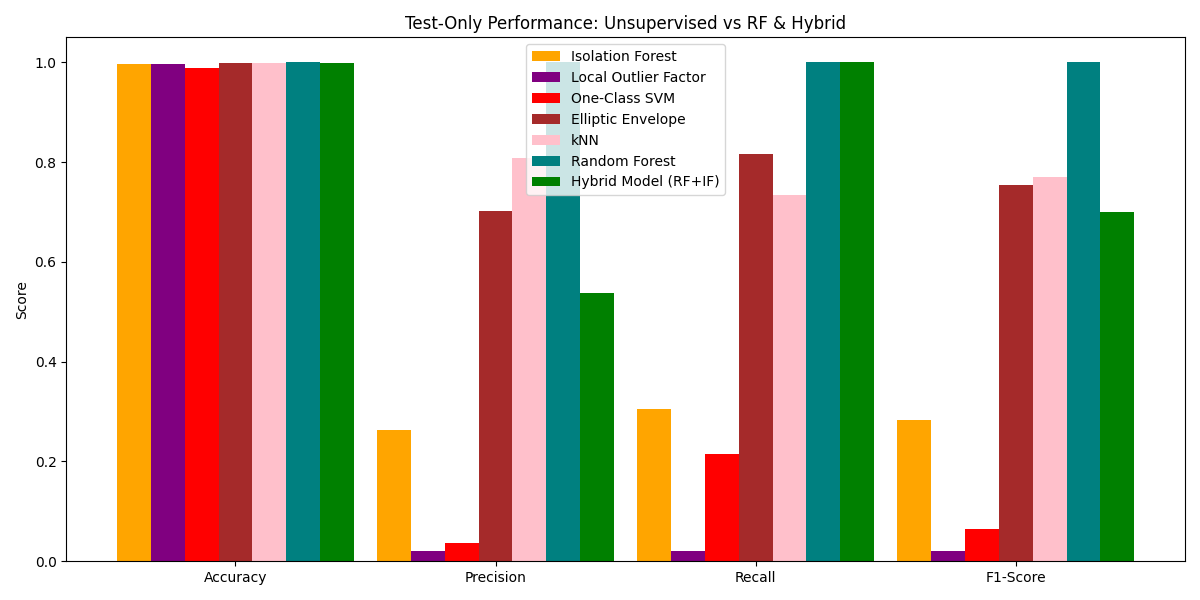

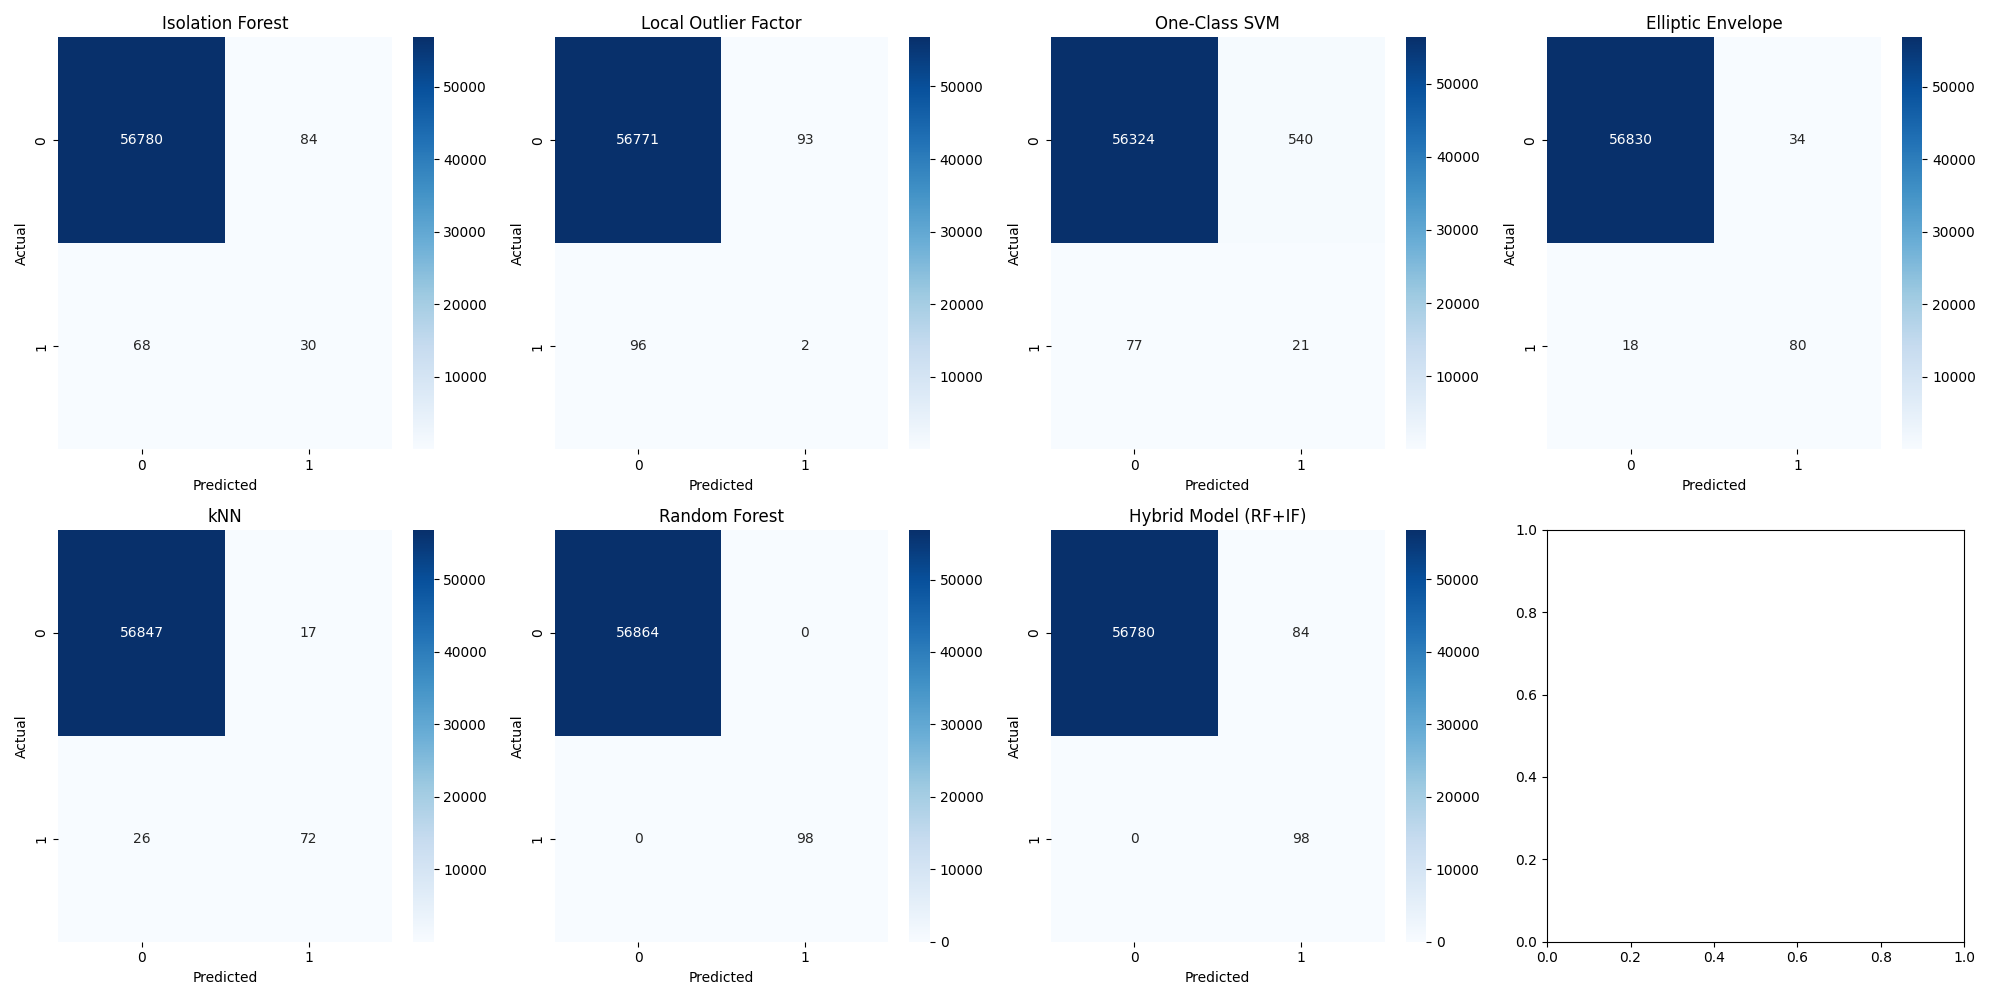


✅ Test-only unsupervised + RF + Hybrid model report saved to 'data/evaluation_report.xlsx'

Top misclassified frauds by Hybrid model (sample of 5):
Empty DataFrame
Columns: [Time, V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, Amount, Actual, RF_Pred, IF_Pred, Hybrid]
Index: []

[0 rows x 34 columns]


In [ ]:
# ---------------------------------------------------------
# Step 3: Unsupervised models predictions (test only)
# ---------------------------------------------------------
# Isolation Forest
if_model = IsolationForest(contamination=0.002, n_estimators=200, max_samples='auto', random_state=42)
if_model.fit(X_test_scaled)
scores_if = -if_model.decision_function(X_test_scaled)
threshold = np.percentile(scores_if, 100 * (1 - 0.002))
y_pred_if = (scores_if >= threshold).astype(int)

# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.002, novelty=True)
lof.fit(X_test_scaled)
y_pred_lof = lof.predict(X_test_scaled)
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)

# One-Class SVM
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.002)
ocsvm.fit(X_test_scaled)
y_pred_ocsvm = ocsvm.predict(X_test_scaled)
y_pred_ocsvm = np.where(y_pred_ocsvm == -1, 1, 0)

# Elliptic Envelope
ee = EllipticEnvelope(contamination=0.002, support_fraction=1.0, random_state=42)
ee.fit(X_test_scaled)
y_pred_ee = np.where(ee.predict(X_test_scaled) == -1, 1, 0)

# kNN Classifier as anomaly detector
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X_test_scaled, y_test)
y_pred_knn = knn.predict(X_test_scaled)

# ---------------------------------------------------------
# Step 4: Random Forest and Hybrid Model
# ---------------------------------------------------------
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_test_scaled, y_test)
y_pred_rf_test = rf.predict(X_test_scaled)

# Hybrid Model: RF + IF
y_pred_combined = np.maximum(y_pred_rf_test, y_pred_if)

# ---------------------------------------------------------
# Step 5: Metrics Computation
# ---------------------------------------------------------
models = {
    "Isolation Forest": y_pred_if,
    "Local Outlier Factor": y_pred_lof,
    "One-Class SVM": y_pred_ocsvm,
    "Elliptic Envelope": y_pred_ee,
    "kNN": y_pred_knn,
    "Random Forest": y_pred_rf_test,
    "Hybrid Model (RF+IF)": y_pred_combined
}

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
scores_dict = {}

for name, pred in models.items():
    rep = classification_report(y_test, pred, output_dict=True)
    scores_dict[name] = [
        accuracy_score(y_test, pred),
        rep["1"]["precision"],
        rep["1"]["recall"],
        rep["1"]["f1-score"]
    ]

# ---------------------------------------------------------
# Step 6: Performance Bar Plot
# ---------------------------------------------------------
plt.figure(figsize=(12,6))
x = np.arange(len(metrics))
width = 0.13
colors = ['orange', 'purple', 'red', 'brown', 'pink', 'teal', 'green']

for i, (name, score) in enumerate(scores_dict.items()):
    plt.bar(x + (i - 3) * width, score, width, label=name, color=colors[i])

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Test-Only Performance: Unsupervised vs RF & Hybrid")
plt.legend()
plt.tight_layout()
comparison_plot = "data/performance_comparison.png"
plt.savefig(comparison_plot)
plt.close()
display(Image(filename=comparison_plot))

# ---------------------------------------------------------
# Step 7: Confusion Matrices
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
conf_plot = "data/confusion_matrices.png"
plt.savefig(conf_plot)
plt.close()
display(Image(filename=conf_plot))

# ---------------------------------------------------------
# Step 8: Save to Excel (metrics + sample outputs + visuals)
# ---------------------------------------------------------
comp_df = pd.DataFrame({"Metric": metrics})
for name, score in scores_dict.items():
    comp_df[name] = np.round(score, 4)

sample_outputs = X_test.copy()
sample_outputs["Actual"] = y_test.values
sample_outputs["RF_Pred"] = y_pred_rf_test
sample_outputs["IF_Pred"] = y_pred_if
sample_outputs["Hybrid"] = y_pred_combined
sample_outputs_sample = sample_outputs.head(20)

with pd.ExcelWriter(excel_file) as writer:
    comp_df.to_excel(writer, index=False, sheet_name="Model Comparison")
    sample_outputs_sample.to_excel(writer, index=False, sheet_name="Sample Outputs")

wb = load_workbook(excel_file)
ws_vis = wb.create_sheet("Visuals")
img1 = ExcelImage(comparison_plot)
img1.anchor = "A1"
ws_vis.add_image(img1)
img2 = ExcelImage(conf_plot)
img2.anchor = "A25"
ws_vis.add_image(img2)
wb.save(excel_file)

# Remove temp images
os.remove(comparison_plot)
os.remove(conf_plot)

print(f"\n✅ Test-only unsupervised + RF + Hybrid model report saved to '{excel_file}'")

# ---------------------------------------------------------
# Step 9: Top misclassified frauds
# ---------------------------------------------------------
misclassified = sample_outputs[(sample_outputs["Actual"]==1) & (sample_outputs["Hybrid"]==0)]
print(f"\nTop misclassified frauds by Hybrid model (sample of 5):\n{misclassified.head(5)}")